In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore")

# Memuat Dataset
historical = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/wind farm historical data.csv")
nwp = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/NWP.csv")

# Preprocessing awal: Pembersihan spasi dan format tanggal
historical.columns = historical.columns.str.strip()
nwp.columns = nwp.columns.str.strip()
historical['Date'] = pd.to_datetime(historical['Date'], dayfirst=True)
nwp['time'] = pd.to_datetime(nwp['time'])

# Penyesuaian nama kolom agar konsisten
historical = historical.rename(columns={'Date':'timestamp', 'Speed':'wind_speed', 'Energy':'power'})
nwp = nwp.rename(columns={'time':'timestamp', 'mod':'wind_speed_nwp', 'temp':'temperature_nwp',
                          'rh':'humidity_nwp', 'mslp':'pressure_nwp'})

# Penggabungan data (Merging) berdasarkan timestamp
data = pd.merge(historical, nwp, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
data = data.ffill().dropna()

In [2]:
data_fe = data.copy()

# 1. Fitur Waktu (Siklus harian)
data_fe['hour'] = data_fe['timestamp'].dt.hour
data_fe['month'] = data_fe['timestamp'].dt.month
data_fe['hour_sin'] = np.sin(2*np.pi*data_fe['hour']/24)
data_fe['hour_cos'] = np.cos(2*np.pi*data_fe['hour']/24)

# 2. Fitur Lag (Data historis sebelumnya)
for lag in [1, 2, 3, 6, 12, 24]:
    data_fe[f'power_lag_{lag}'] = data_fe['power'].shift(lag)

# 3. Fitur Fisik (Berdasarkan Dynamic Pressure Model di Jurnal)
data_fe['temp_kelvin'] = data_fe['temperature_nwp'] + 273.15
data_fe['pressure_pascal'] = data_fe['pressure_nwp'] * 100
R_specific = 287.058 # Konstanta gas ideal untuk udara kering

# Menghitung Kerapatan Udara (Air Density)
data_fe['air_density'] = data_fe['pressure_pascal'] / (R_specific * data_fe['temp_kelvin'])

# Menghitung Theoretical Power (P = 0.5 * rho * v^3)
data_fe['physics_theoretical_power'] = 0.5 * data_fe['air_density'] * (data_fe['wind_speed_nwp']**3)

data_fe = data_fe.dropna().reset_index(drop=True)

In [3]:
# Menentukan fitur yang digunakan untuk prediksi
features = data_fe.drop(['timestamp', 'power', 'month'], axis=1, errors='ignore').columns
test_months = [10, 11, 12] # Pengujian pada kuartal terakhir
results_xgb = []

# Ruang lingkup parameter untuk GridSearchCV
param_grid_xgb = {
    'n_estimators': [500, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

for month in test_months:
    train_data = data_fe[data_fe['month'] < month]
    test_data = data_fe[data_fe['month'] == month]

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_data[features])
    X_test = scaler.transform(test_data[features])
    y_train = train_data['power']
    y_test = test_data['power']

    # --- Skenario 1: XGBoost Default ---
    model_def = XGBRegressor(objective='reg:squarederror', random_state=42)
    model_def.fit(X_train, y_train)
    pred_def = model_def.predict(X_test)

    results_xgb.append({
        'Month': month, 'Model': 'XGBoost (Default)',
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_def)),
        'MAE': mean_absolute_error(y_test, pred_def),
        'R2': r2_score(y_test, pred_def)
    })

    # --- Skenario 2: XGBoost Tuned (Grid Search) ---
    tscv = TimeSeriesSplit(n_splits=3) # Validasi khusus data waktu
    grid_search = GridSearchCV(
        estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
        param_grid=param_grid_xgb, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    pred_tuned = grid_search.best_estimator_.predict(X_test)

    results_xgb.append({
        'Month': month, 'Model': 'XGBoost (Tuned)',
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_tuned)),
        'MAE': mean_absolute_error(y_test, pred_tuned),
        'R2': r2_score(y_test, pred_tuned)
    })
    print(f"Bulan {month} selesai. Best Params: {grid_search.best_params_}")

Bulan 10 selesai. Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Bulan 11 selesai. Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Bulan 12 selesai. Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}



=== Performa Rata-rata Model ===
                         RMSE        MAE        R2
Model                                             
XGBoost (Default)  144.040381  93.516474  0.896777
XGBoost (Tuned)    135.672523  89.499750  0.907848


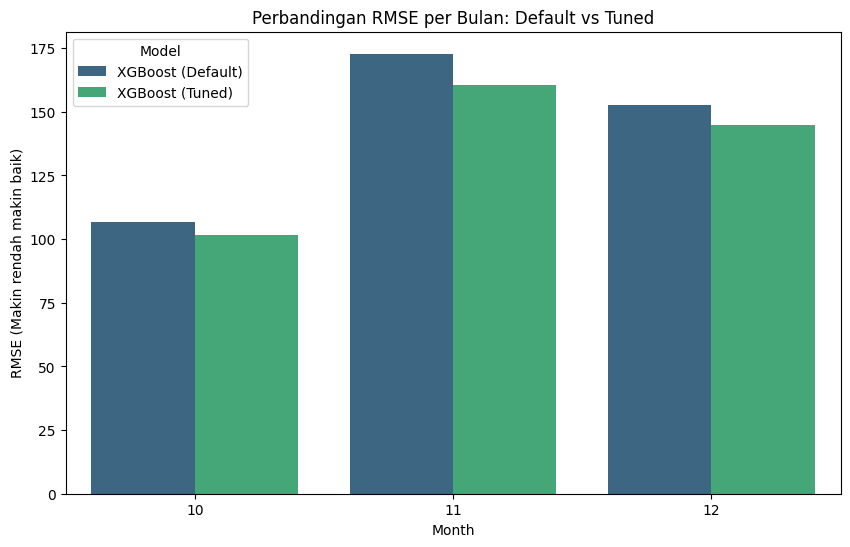

In [4]:
xgb_df = pd.DataFrame(results_xgb)
print("\n=== Performa Rata-rata Model ===")
print(xgb_df.groupby('Model')[['RMSE', 'MAE', 'R2']].mean())

# Visualisasi RMSE per Bulan
plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_df, x='Month', y='RMSE', hue='Model', palette='viridis')
plt.title('Perbandingan RMSE per Bulan: Default vs Tuned')
plt.ylabel('RMSE (Makin rendah makin baik)')
plt.show()

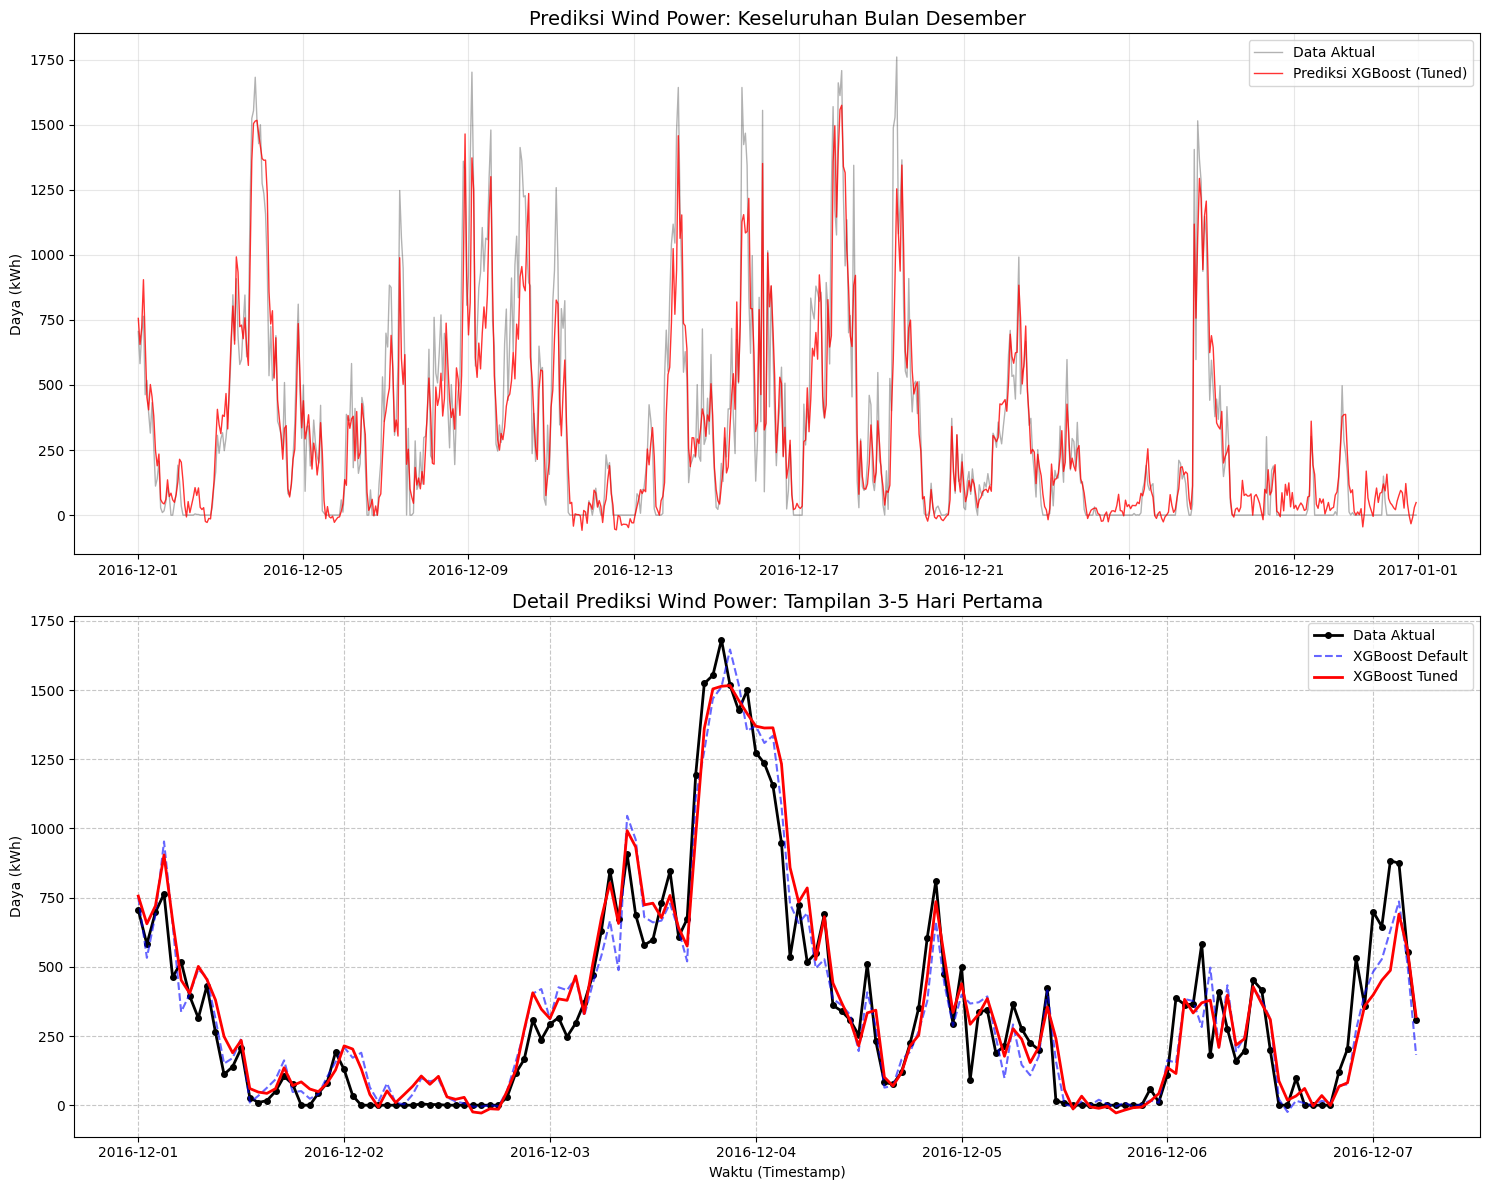

In [5]:
# =====================================================
# 1. PERSIAPAN DATA UNTUK GRAFIK
# =====================================================
# Kita ambil data aktual dan hasil prediksi dari salah satu pengujian (misal bulan 12)
# y_test: Data aktual
# pred_def: Hasil prediksi XGBoost Default
# pred_tuned: Hasil prediksi XGBoost Teroptimasi (Grid Search)

# Membuat DataFrame khusus untuk plotting agar mudah dikelola
plot_df = pd.DataFrame({
    'Timestamp': test_data['timestamp'],
    'Aktual': y_test.values,
    'XGBoost_Default': pred_def,
    'XGBoost_Tuned': pred_tuned
}).reset_index(drop=True)

# =====================================================
# 2. VISUALISASI: LINE CHART (OVERALL & ZOOMED)
# =====================================================
import matplotlib.pyplot as plt

# Membuat dua grafik berdampingan (Atas: Keseluruhan Bulan, Bawah: Zoom-in 3 Hari)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# --- Grafik 1: Performa Keseluruhan (Bulan Desember) ---
ax1.plot(plot_df['Timestamp'], plot_df['Aktual'], label='Data Aktual', color='black', alpha=0.3, linewidth=1)
ax1.plot(plot_df['Timestamp'], plot_df['XGBoost_Tuned'], label='Prediksi XGBoost (Tuned)', color='red', alpha=0.8, linewidth=1)
ax1.set_title('Prediksi Wind Power: Keseluruhan Bulan Desember', fontsize=14)
ax1.set_ylabel('Daya (kWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Grafik 2: Zoom-In (Melihat Detail Prediksi dalam 3 Hari) ---
# Kita ambil 72 baris pertama (asumsi data per jam, maka 72 jam = 3 hari)
# Jika data Anda per 10 menit, gunakan 144 atau sesuai kebutuhan.
subset_df = plot_df.head(150)

ax2.plot(subset_df['Timestamp'], subset_df['Aktual'], label='Data Aktual', color='black', marker='o', markersize=4, linewidth=2)
ax2.plot(subset_df['Timestamp'], subset_df['XGBoost_Default'], label='XGBoost Default', linestyle='--', color='blue', alpha=0.6)
ax2.plot(subset_df['Timestamp'], subset_df['XGBoost_Tuned'], label='XGBoost Tuned', color='red', linewidth=2)

ax2.set_title('Detail Prediksi Wind Power: Tampilan 3-5 Hari Pertama', fontsize=14)
ax2.set_xlabel('Waktu (Timestamp)')
ax2.set_ylabel('Daya (kWh)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()